# LSTM Network - LSTM Model for New York Temperature Forecasting

In [133]:
# importar bibliotecas de interesse
import numpy as np 
import pandas as pd 
 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
 


In [135]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras import metrics

In [136]:

 
df = pd.read_csv('NY.csv')

In [137]:
df = pd.read_csv('NY.csv', header=None)

In [138]:
display(df.tail()) # Temperatura em Fahrenheit  
# °C = (°F - 32)/1,8

,0,1,2,3,4,5,6
336,USW00014732,"LA GUARDIA AIRPORT, NY US",6/2/2018,NaN,78,87,67
337,USW00014732,"LA GUARDIA AIRPORT, NY US",6/3/2018,NaN,66,67,53
338,USW00014732,"LA GUARDIA AIRPORT, NY US",6/4/2018,NaN,59,72,52
339,USW00014732,"LA GUARDIA AIRPORT, NY US",6/5/2018,NaN,67,77,59
340,USW00014732,"LA GUARDIA AIRPORT, NY US",6/6/2018,NaN,66,71,60


In [139]:
display(df.head())

,0,1,2,3,4,5,6
0,USW00014732,"LA GUARDIA AIRPORT, NY US",7/1/2017,NaN,79,85,74
1,USW00014732,"LA GUARDIA AIRPORT, NY US",7/2/2017,NaN,80,91,73
2,USW00014732,"LA GUARDIA AIRPORT, NY US",7/3/2017,NaN,83,90,73
3,USW00014732,"LA GUARDIA AIRPORT, NY US",7/4/2017,NaN,78,87,70
4,USW00014732,"LA GUARDIA AIRPORT, NY US",7/5/2017,NaN,77,85,70


In [140]:
TAVG = np.array([df.iloc[:,6]])
TMAX = np.array([df.iloc[:,5]])
TMIN = np.array([df.iloc[:,4]])
 
print(TAVG)

[[74 73 73 70 70 69 68 71 70 72 75 78 73 65 67 71 75 76 78 77 77 73 72 64
  62 65 67 71 68 66 70 72 69 70 71 70 66 66 65 68 71 72 65 72 71 69 71 70
  73 75 71 75 74 74 69 66 64 64 64 61 61 66 56 56 59 64 71 61 61 61 58 59
  59 63 67 70 70 69 69 68 69 71 72 68 70 71 71 68 70 61 57 55 52 56 59 58
  66 70 66 71 71 69 62 56 53 62 66 48 45 52 58 62 58 58 61 67 59 52 51 54
  61 47 48 47 58 53 48 52 48 41 40 42 27 26 34 42 39 38 45 41 36 40 37 43
  37 34 37 42 42 42 37 44 40 43 40 42 40 50 41 40 36 31 32 35 32 22 24 23
  25 33 34 46 36 34 36 38 36 28 24 18 12 12 18 10  8 14 17 20 10  8  6 18
  30 26 35 37 20 15 16 24 23 20 26 37 42 36 36 28 24 28 35 42 34 26 19 33
  18 17 31 28 28 30 26 28 38 42 34 27 36 47 37 30 33 33 47 50 37 36 43 40
  44 40 42 43 36 38 35 35 34 34 34 31 33 34 33 34 32 34 32 29 30 34 31 32
  33 37 37 35 34 35 39 46 43 40 43 32 39 41 35 37 38 33 33 40 38 46 59 45
  39 40 40 39 40 38 41 46 45 46 50 53 49 51 48 44 50 65 70 68 61 54 56 54
  54 56 60 53 52 52 60 55 55 56 50 55 

In [141]:
TMAX

array([[85, 91, 90, 87, 85, 81, 82, 87, 85, 88, 89, 91, 94, 73, 86, 86,
        87, 88, 94, 98, 94, 91, 80, 73, 71, 78, 78, 84, 76, 82, 89, 91,
        88, 87, 85, 80, 78, 73, 80, 85, 86, 82, 78, 85, 83, 76, 86, 82,
        83, 89, 83, 88, 91, 82, 81, 78, 77, 77, 75, 69, 80, 82, 72, 68,
        72, 82, 85, 74, 75, 73, 69, 73, 78, 82, 84, 83, 82, 80, 81, 74,
        78, 78, 79, 81, 86, 91, 86, 81, 84, 77, 70, 66, 70, 74, 71, 75,
        84, 82, 82, 80, 79, 81, 78, 65, 68, 73, 75, 71, 61, 74, 72, 74,
        79, 76, 75, 76, 68, 59, 63, 68, 68, 62, 58, 59, 72, 75, 56, 62,
        66, 51, 50, 56, 53, 39, 47, 50, 47, 51, 59, 49, 56, 60, 48, 59,
        55, 45, 51, 58, 53, 52, 53, 64, 54, 53, 48, 48, 52, 60, 59, 46,
        41, 37, 40, 43, 51, 33, 33, 30, 40, 37, 48, 56, 53, 41, 51, 53,
        41, 39, 29, 25, 19, 22, 24, 22, 19, 26, 30, 29, 20, 15, 18, 33,
        43, 40, 47, 60, 53, 24, 30, 34, 36, 33, 40, 54, 52, 45, 60, 45,
        35, 39, 57, 54, 44, 37, 34, 45, 39, 32, 47, 41, 38, 47, 

In [142]:
# figura para ver os dados em 3 dimensões

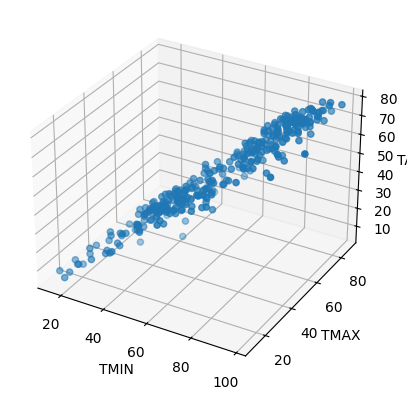

In [143]:
fig = plt.figure(1)
ax = fig.add_subplot(111,projection='3d')
#111: É uma forma abreviada de (1, 1, 1). Isso significa que você está dividindo a figura 
#em uma grade de 1 linha por 1 coluna, e o gráfico que você está adicionando é o primeiro (e único) nessa grade. 
#Ou seja, ele ocupa toda a área da figura.


ax.scatter(TMAX,TMIN,TAVG,marker= 'o')
ax.set_xlabel('TMIN')
ax.set_ylabel('TMAX')
ax.set_zlabel('TAVG')
plt.show()

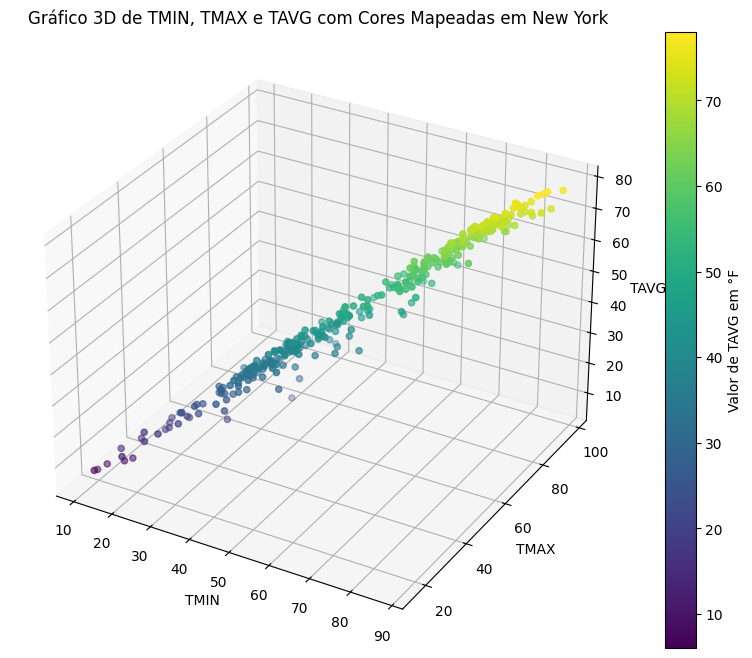

In [144]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# A mudança está aqui:
# 'c' recebe os valores da variável que você quer mapear para cores (TAVG, neste caso)
# 'cmap' define a paleta de cores a ser usada
scatter = ax.scatter(TMIN, TMAX, TAVG, marker='o', c=TAVG, cmap='viridis')

# É crucial adicionar uma barra de cores para servir de legenda
fig.colorbar(scatter, ax=ax, label='Valor de TAVG em °F')

ax.set_xlabel('TMIN')
ax.set_ylabel('TMAX')
ax.set_zlabel('TAVG')
ax.set_title('Gráfico 3D de TMIN, TMAX e TAVG com Cores Mapeadas em New York')

plt.show()

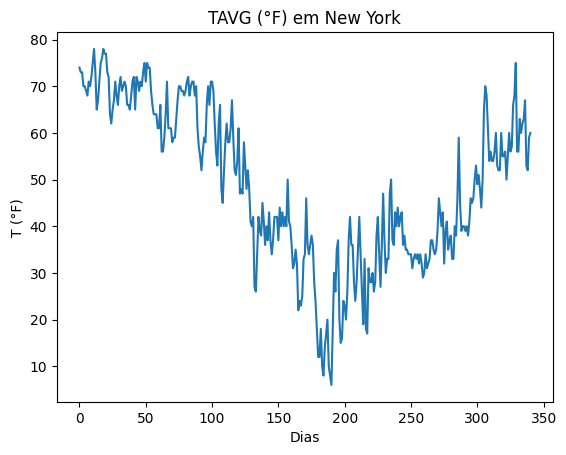

In [145]:
plt.plot(TAVG[0,:])

plt.ylabel('T (°F)')  
plt.xlabel('Dias')    
plt.title('TAVG (°F) em New York')
plt.show()
 

In [146]:
X = np.concatenate([TMIN,TMAX],axis=0)


In [147]:
print(X)

[[79 80 83 78 77 74 72 78 76 79 80 84 86 70 74 78 80 80 85 87 84 85 76 70
  66 71 72 77 73 73 78 81 80 76 78 76 72 70 70 76 78 76 72 77 77 73 77 76
  77 80 79 81 81 78 75 72 71 70 70 67 67 74 65 63 63 71 76 70 65 67 64 65
  68 72 74 75 77 74 73 71 72 74 76 74 76 80 78 74 75 74 63 62 59 65 64 65
  73 75 72 74 74 75 71 63 59 66 70 63 52 60 65 67 68 67 67 71 65 58 56 61
  64 57 54 51 63 66 53 55 63 48 43 48 44 31 40 45 43 44 52 45 44 53 43 49
  52 39 43 49 49 45 44 54 44 50 44 45 45 54 50 43 39 35 35 38 44 29 28 26
  31 36 38 50 48 37 40 41 40 36 27 23 17 15 20 18 13 18 23 26 17 12 11 22
  35 34 40 48 42 20 22 28 34 26 31 43 46 42 45 43 29 32 42 50 43 34 26 37
  33 22 35 37 32 33 33 31 42 46 48 33 40 51 56 36 38 42 54 62 51 38 47 42
  46 47 49 54 42 41 42 38 40 37 37 37 37 39 38 37 37 39 38 36 37 40 36 36
  40 43 43 40 40 39 44 50 50 47 50 40 41 46 42 45 46 39 39 43 44 51 65 62
  44 47 46 45 46 43 49 55 53 55 56 60 54 57 54 49 60 77 82 76 70 63 62 62
  63 59 65 59 54 58 69 63 60 65 54 67 

In [148]:
X = np.transpose(X)
print(X)


[[79 85]
 [80 91]
 [83 90]
 [78 87]
 [77 85]
 [74 81]
 [72 82]
 [78 87]
 [76 85]
 [79 88]
 [80 89]
 [84 91]
 [86 94]
 [70 73]
 [74 86]
 [78 86]
 [80 87]
 [80 88]
 [85 94]
 [87 98]
 [84 94]
 [85 91]
 [76 80]
 [70 73]
 [66 71]
 [71 78]
 [72 78]
 [77 84]
 [73 76]
 [73 82]
 [78 89]
 [81 91]
 [80 88]
 [76 87]
 [78 85]
 [76 80]
 [72 78]
 [70 73]
 [70 80]
 [76 85]
 [78 86]
 [76 82]
 [72 78]
 [77 85]
 [77 83]
 [73 76]
 [77 86]
 [76 82]
 [77 83]
 [80 89]
 [79 83]
 [81 88]
 [81 91]
 [78 82]
 [75 81]
 [72 78]
 [71 77]
 [70 77]
 [70 75]
 [67 69]
 [67 80]
 [74 82]
 [65 72]
 [63 68]
 [63 72]
 [71 82]
 [76 85]
 [70 74]
 [65 75]
 [67 73]
 [64 69]
 [65 73]
 [68 78]
 [72 82]
 [74 84]
 [75 83]
 [77 82]
 [74 80]
 [73 81]
 [71 74]
 [72 78]
 [74 78]
 [76 79]
 [74 81]
 [76 86]
 [80 91]
 [78 86]
 [74 81]
 [75 84]
 [74 77]
 [63 70]
 [62 66]
 [59 70]
 [65 74]
 [64 71]
 [65 75]
 [73 84]
 [75 82]
 [72 82]
 [74 80]
 [74 79]
 [75 81]
 [71 78]
 [63 65]
 [59 68]
 [66 73]
 [70 75]
 [63 71]
 [52 61]
 [60 74]
 [65 72]
 

In [149]:
Y = np.transpose(TAVG)
Y[:20]

array([[74],
       [73],
       [73],
       [70],
       [70],
       [69],
       [68],
       [71],
       [70],
       [72],
       [75],
       [78],
       [73],
       [65],
       [67],
       [71],
       [75],
       [76],
       [78],
       [77]])

In [150]:
# normalizar
sc= MinMaxScaler()
sc.fit(X)
print(sc)

MinMaxScaler()


In [151]:
X=sc.transform(X)
X[:20]

array([[0.89473684, 0.84337349],
       [0.90789474, 0.91566265],
       [0.94736842, 0.90361446],
       [0.88157895, 0.86746988],
       [0.86842105, 0.84337349],
       [0.82894737, 0.79518072],
       [0.80263158, 0.80722892],
       [0.88157895, 0.86746988],
       [0.85526316, 0.84337349],
       [0.89473684, 0.87951807],
       [0.90789474, 0.89156627],
       [0.96052632, 0.91566265],
       [0.98684211, 0.95180723],
       [0.77631579, 0.69879518],
       [0.82894737, 0.85542169],
       [0.88157895, 0.85542169],
       [0.90789474, 0.86746988],
       [0.90789474, 0.87951807],
       [0.97368421, 0.95180723],
       [1.        , 1.        ]])

In [152]:
sc1= MinMaxScaler()
sc1.fit(Y)
sc1

MinMaxScaler()

In [153]:
sc1.get_params()

{'clip': False, 'copy': True, 'feature_range': (0, 1)}

In [154]:
Y=sc1.transform(Y)
Y[:20]


array([[0.94444444],
       [0.93055556],
       [0.93055556],
       [0.88888889],
       [0.88888889],
       [0.875     ],
       [0.86111111],
       [0.90277778],
       [0.88888889],
       [0.91666667],
       [0.95833333],
       [1.        ],
       [0.93055556],
       [0.81944444],
       [0.84722222],
       [0.90277778],
       [0.95833333],
       [0.97222222],
       [1.        ],
       [0.98611111]])

In [155]:
# criando 3 dimensões
X = np.reshape(X,(X.shape[0],1,X.shape[1]))


In [156]:
print(X[1:5])

[[[0.90789474 0.91566265]]

 [[0.94736842 0.90361446]]

 [[0.88157895 0.86746988]]

 [[0.86842105 0.84337349]]]


In [157]:
X.shape

(341, 1, 2)

In [158]:

# separar 30% para o teste e o resto para o treino

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)

In [159]:
print(X_train[1:5])

print(Y_train[1:5])

[[[0.93421053 0.92771084]]

 [[0.32894737 0.30120482]]

 [[0.85526316 0.77108434]]

 [[0.48684211 0.54216867]]]
[[0.95833333]
 [0.36111111]
 [0.91666667]
 [0.43055556]]


In [160]:
# x tmin e tmax e y é a média

In [161]:
model = Sequential()
# model = Sequential(): Inicia a criação do modelo. Sequential significa que as camadas da rede serão empilhadas 
#uma após a outra em uma ordem linear.

In [162]:
model

<Sequential name=sequential_2, built=False>

In [163]:
model.add(LSTM(20,activation='tanh',input_shape=(1,2),recurrent_activation='hard_sigmoid')) 
# antes era 10 agora 20 os números de neurônios => para melhorar a previsão dos picos e da acurácia

/home/fabiene/anaconda3/envs/YouTube/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



model.add(LSTM(...)): Adiciona a primeira camada do modelo, do tipo LSTM (uma rede neural recorrente). Essa camada é ideal para analisar dados sequenciais. O 20 representa o número de neurônios, e input_shape=(1,2) informa que o modelo espera dados com uma sequência de 1 passo de tempo e 2 características.



In [164]:
# input_shape=(1,2) 1 saída y e 2 dado de entrada X

O parâmetro recurrent_activation='hard_sigmoid' define a função de ativação para as portas internas (gates) de uma camada recorrente.

recurrent_activation: Controla como a camada decide qual informação deve ser mantida, esquecida ou enviada para a próxima etapa. É com "chaves" internas que abrem e fecham o fluxo de informações dentro da célula neural.

'hard_sigmoid': É a função de ativação específica escolhida. Ela é uma aproximação linear e mais rápida da função sigmoid padrão. Usá-la nas portas da LSTM geralmente resulta em um treinamento mais rápido sem comprometer a performance do modelo, sendo uma escolha muito comum.

In [165]:
model.add(Dense(1))

model.add(Dense(1)): Adiciona a camada de saída. Dense é uma camada totalmente conectada, e o 1 indica que ela tem apenas um neurônio. Essa é uma configuração comum para problemas de regressão, onde o objetivo é prever um único valor contínuo.

In [166]:
model.compile(loss= 'mean_squared_error',optimizer= 'rmsprop',metrics=['mae'])

model.compile(...): Prepara o modelo para o treinamento. loss define como o modelo medirá seu erro (mean_squared_error é para regressão), optimizer é o algoritmo que o modelo usará para aprender (rmsprop é um otimizador popular), e metrics são métricas para você acompanhar o desempenho (mae é o erro absoluto médio).

In [167]:
model.fit(X_train,Y_train,epochs=50,verbose= 2) # antes tentou com epochs 20 depois alterou para 50 =>
#para melhorar a previsão dos picos e da acurácia


Epoch 1/50
8/8 - 1s - 171ms/step - loss: 0.3027 - mae: 0.5077
Epoch 2/50
8/8 - 0s - 7ms/step - loss: 0.2421 - mae: 0.4480
Epoch 3/50
8/8 - 0s - 9ms/step - loss: 0.2004 - mae: 0.4046
Epoch 4/50
8/8 - 0s - 8ms/step - loss: 0.1642 - mae: 0.3617
Epoch 5/50
8/8 - 0s - 10ms/step - loss: 0.1335 - mae: 0.3227
Epoch 6/50
8/8 - 0s - 12ms/step - loss: 0.1060 - mae: 0.2836
Epoch 7/50
8/8 - 0s - 11ms/step - loss: 0.0819 - mae: 0.2451
Epoch 8/50
8/8 - 0s - 17ms/step - loss: 0.0612 - mae: 0.2079
Epoch 9/50
8/8 - 0s - 14ms/step - loss: 0.0444 - mae: 0.1733
Epoch 10/50
8/8 - 0s - 13ms/step - loss: 0.0316 - mae: 0.1430
Epoch 11/50
8/8 - 0s - 9ms/step - loss: 0.0226 - mae: 0.1194
Epoch 12/50
8/8 - 0s - 12ms/step - loss: 0.0168 - mae: 0.1051
Epoch 13/50
8/8 - 0s - 12ms/step - loss: 0.0137 - mae: 0.0969
Epoch 14/50
8/8 - 0s - 10ms/step - loss: 0.0122 - mae: 0.0939
Epoch 15/50
8/8 - 0s - 14ms/step - loss: 0.0112 - mae: 0.0894
Epoch 16/50
8/8 - 0s - 14ms/step - loss: 0.0102 - mae: 0.0853
Epoch 17/50
8/8 - 0s

model.fit(X_train,Y_train,epochs=50,verbose= 2)

model.fit(X_train,Y_train,...): Inicia o treinamento do modelo. Ele usa X_train como dados de entrada e Y_train como os valores corretos. epochs=50 significa que o modelo vai passar por todo o conjunto de dados 50 vezes, e verbose=2 faz com que o progresso do treinamento seja exibido na tela.

8/8: Mostra que o modelo processou todos os 8 lotes de dados (batches) que compõem o seu conjunto de treinamento.

0s: É o tempo total que levou para o modelo processar esta época completa.

7ms/step: Indica o tempo médio que o modelo levou para processar cada lote de dados.

loss: 0.0026 - mae: 0.0385
loss: 0.0026: Este é o valor da função de perda (mean_squared_error) no final da época. O valor é muito baixo, o que é um ótimo sinal! Ele indica que a diferença entre os valores previstos pelo modelo e os valores reais é mínima.

mae: 0.0385: Este é o valor da métrica Erro Absoluto Médio (MAE). Ele representa a média do erro de previsão do seu modelo, na mesma unidade dos seus dados. Um valor de 0.0385 é bastante baixo e sugere que o modelo está fazendo previsões com alta precisão.

Em resumo, a resposta informa que o modelo terminou de treinar, processando todos os dados. Os valores muito baixos de loss e mae indicam que o treinamento foi bem-sucedido e que o modelo aprendeu a fazer previsões com um erro mínimo.


No treino de redes neurais, época (ou epoch) é uma passada completa de todo o conjunto de treino pelo modelo.

- exemplo:

Você tem 100 amostras no X_train.

O modelo vai processar todas essas 100 amostras uma vez → isso é 1 época.

Na próxima época, ele repete o processo, mas agora com pesos um pouco ajustados pela época anterior.

- Por que usar várias épocas:

Porque o modelo não aprende tudo de uma vez. Cada época faz ajustes pequenos nos pesos para diminuir o erro. Com várias épocas, ele refina as previsões até convergir (ou até começar a overfitar).

- Observação:

Mais épocas ≠ melhor sempre.

Poucas épocas → modelo não aprende o suficiente (underfitting).

Muitas épocas → modelo memoriza demais e perde capacidade de generalizar (overfitting).


In [168]:
predict =model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


predict = model.predict(X_test): Usa o modelo já treinado para fazer previsões com novos dados. X_test são os dados que o modelo nunca viu, e o resultado da previsão é armazenado na variável predict.

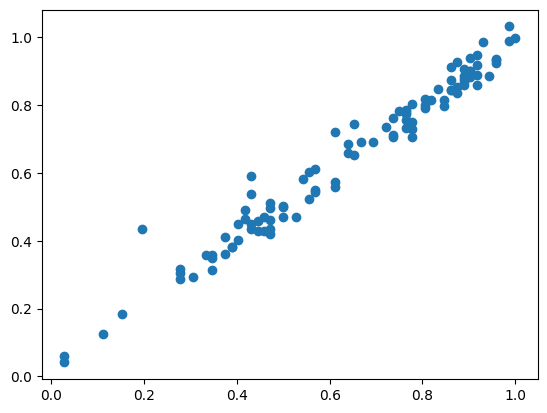

In [169]:
plt.figure(2)
plt.scatter(Y_test,predict)
#plt.show(block=False)
plt.show()

## para verificar acurácia

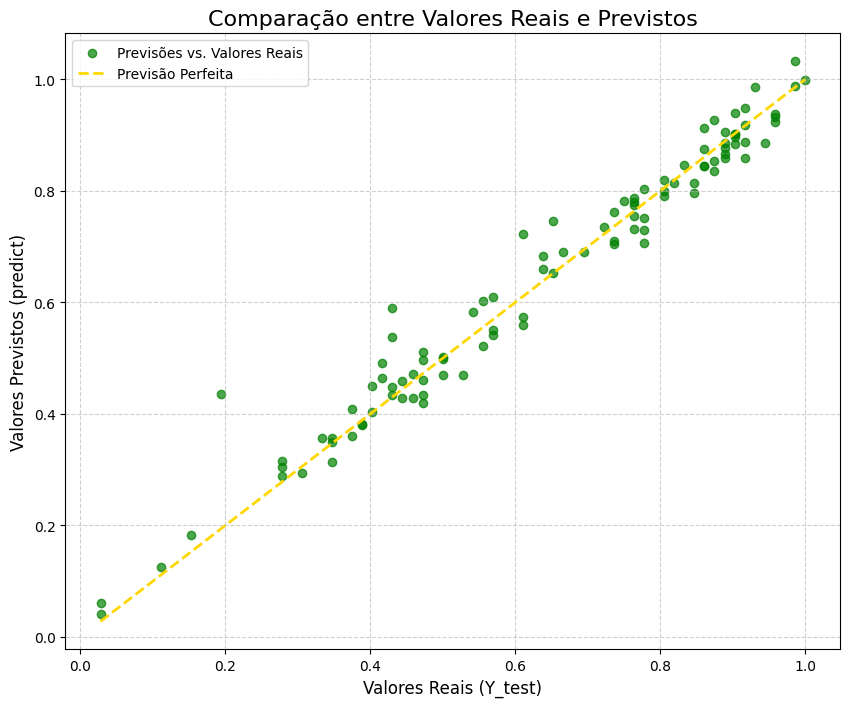

In [170]:
# Cria a figura com um tamanho maior para melhor visualização
plt.figure(figsize=(10, 8))

# Plota os pontos de teste com a cor 'verde'
# Cada ponto representa um par de (Y_test[i], predict[i])
plt.scatter(Y_test, predict, color='green', alpha=0.7, label='Previsões vs. Valores Reais')

# Adiciona a linha de previsão perfeita (Y=X) na cor 'amarelo'
# Esta linha é o que o seu modelo deveria prever se fosse perfeito
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()],
         color='gold', linestyle='--', linewidth=2, label='Previsão Perfeita')

# Adiciona títulos e rótulos
plt.title('Comparação entre Valores Reais e Previstos', fontsize=16)
plt.xlabel('Valores Reais (Y_test)', fontsize=12)
plt.ylabel('Valores Previstos (predict)', fontsize=12)

# Adiciona a legenda e uma grade
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

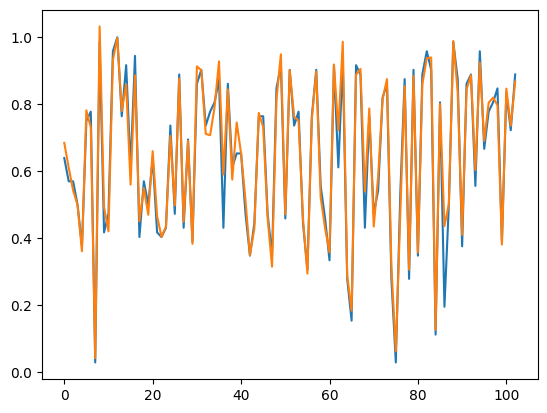

In [171]:
plt.figure(3)
Real = plt.plot(Y_test)
Predict = plt.plot(predict)
plt.show()

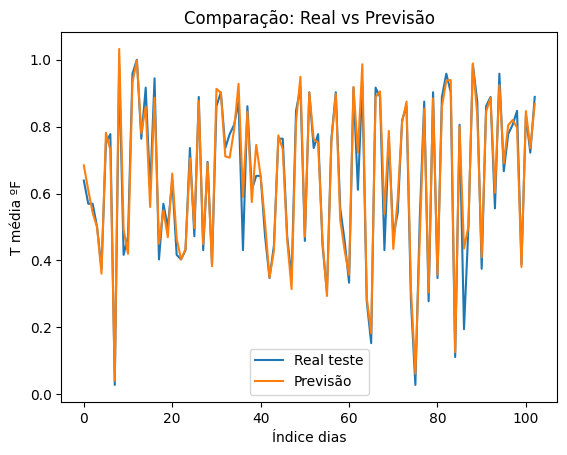

In [172]:
plt.figure(10)
plt.plot(Y_test, label='Real teste')      
plt.plot(predict, label='Previsão')   
plt.legend()                        
plt.title('Comparação: Real vs Previsão')
plt.xlabel('Índice dias')
plt.ylabel('T média ºF')
plt.show()